Answers for Week 5

* Name: Noah Demmenie
* Username: ndemmenie
* Student s-number: S6294588
* Group (AS1, etc.): AS3

**Question 5.2 : Functions loadtxt() and savetxt():**

In [16]:
import numpy as np

# Users input for filename

filename = input("Enter filename: ")
data = np.loadtxt(filename)

# Extract data

x = data[:,0]
y = data[:,1]

# Compute mins, max' and means

x_min = min(x)
y_min = min(y)
x_max = max(x)
y_max = max(y)

x_mean = np.mean(x)
y_mean = np.mean(y)

print(f"x_min = {x_min}")
print(f"y_min = {y_min}")
print(f"x_max = {x_max}")
print(f"y_max = {y_max}")
print(f"x_mean = {x_mean}")
print(f"y_mean = {y_mean}")

# Compute y2

y_med = np.median(y)
y2 = (y - y_med)**2

print(f"y2 = {y2}")

Enter filename:  data.txt


x_min = 1.2
y_min = 1.9
x_max = 10.0
y_max = 9.0
x_mean = 5.79
y_mean = 5.22
y2 = [ 0.4225  0.9025  6.0025  8.1225 12.6025  0.4225 18.0625  4.2025  3.0625
  2.1025]


**Question 5.6 : Array concatenation:**

In [13]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.concatenate((a, b)))

[1 2 3 4 5 6]


It combines them into a longer array

In [2]:
import numpy as np

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print(np.concatenate((a, b)))
print(np.concatenate((a, b), axis=0))
print(np.concatenate((a, b), axis=1))

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]


For 2D arrays, axis=0 stacks the arrays on top of eachother (more rows) and axis=1 stacks them next to eachother (more columns).

**Question 5.9 : Exploring artificial image colors:**

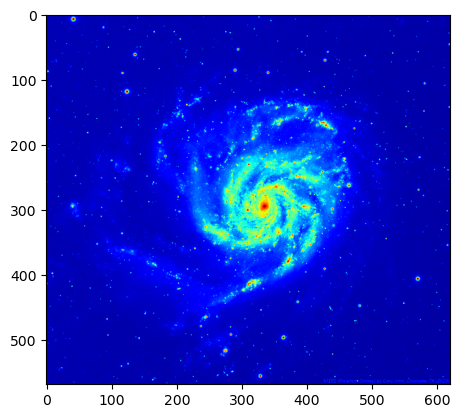

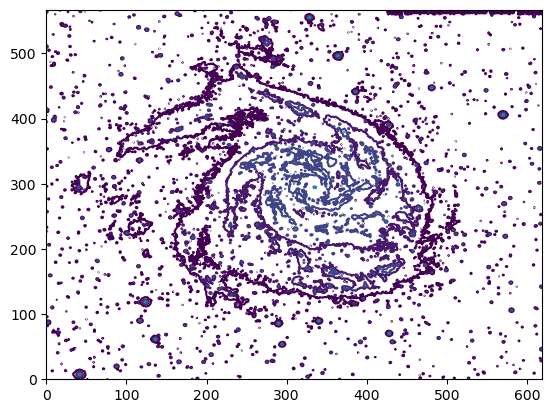

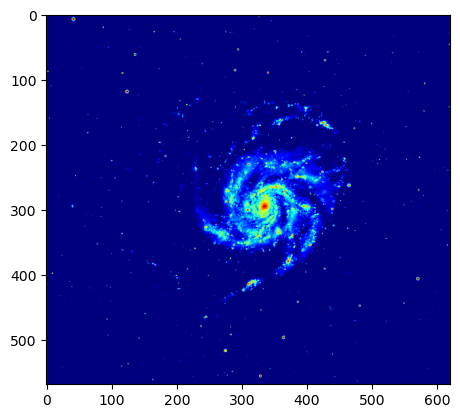

In [46]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio

data = imageio.imread("m101BW.jpg")

# Plot image

plt.imshow(data, cmap = 'jet')
plt.show()

# Plot contour

plt.contour(data, levels=[30, 60, 120, 240, 480])
plt.show()

# Compute data with highest intensities

cutoff_part = np.percentile(data, 90)
bright_pixels = np.where(data >= cutoff_part, data, cutoff_part)

# Plot data

plt.imshow(bright_pixels, cmap = 'jet')
plt.show()

**Question 5.10 : Slicing in a multi dimensional array:**

z_profile = [0.00482 0.00666 0.00705 0.00889 0.01269 0.02012 0.02789 0.03712 0.03985
 0.04617 0.0606  0.04935 0.02734 0.01746 0.0149  0.0247  0.03478 0.03472
 0.03174 0.02931 0.02995 0.02909 0.02687 0.0247  0.02483 0.02504 0.02486
 0.0228  0.01888 0.01625 0.01589 0.01473 0.01294 0.01236 0.01144 0.01118
 0.01038 0.00848 0.00751 0.0072 ]


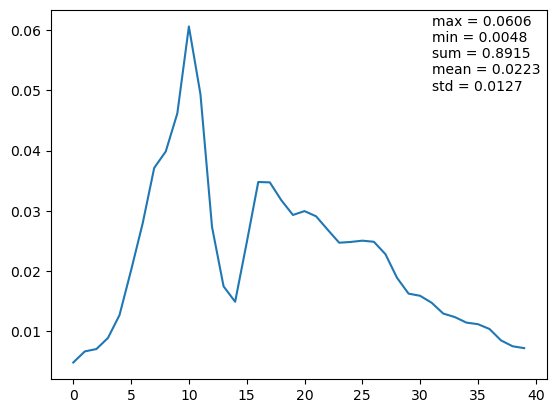

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Define and reshape data

data = np.loadtxt("ngc6946.txt")
data3D = data.reshape(40, 50, 70)

# Compute z profile in the middle of the x,y plane

y_mid = int(50 / 2)
x_mid = int(70 / 2)
z_profile = data3D[:, y_mid, x_mid]
print(f"z_profile = {z_profile}")

# Compute statistics of z profile

z_max = max(z_profile)
z_min = min(z_profile)
z_sum = sum(z_profile)
z_mean = np.mean(z_profile) 
z_std = np.std(z_profile)

# Plot z profile with its statistics

plt.plot(z_profile)
text = f"max = {z_max}\nmin = {z_min:.4f}\nsum = {z_sum:.4}\nmean = {z_mean:.4f}\nstd = {z_std:.4f}"
plt.text(31, 0.05, text)
plt.show()
plt.show()

**Question 5.11 : Extract images of a 3D cube:**

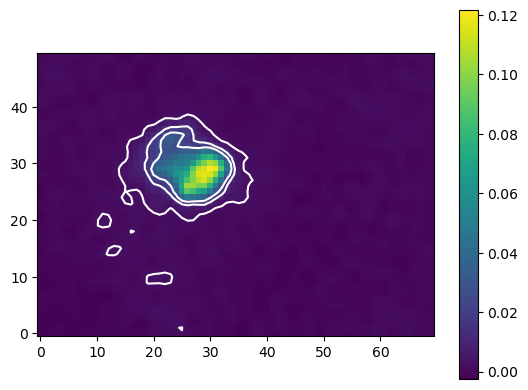

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# Reshape and extract data

data = np.loadtxt("ngc6946.txt")
data3D = data.reshape(40, 50, 70)
data_firstplane = data3D[0]

# Plot image

plt.imshow(data_firstplane, origin = 'lower')
plt.colorbar()

# Compute and plot contours

data_mean = np.mean(data_firstplane)
data_std = np.std(data_firstplane)
plt.contour(data_firstplane, levels = [data_mean, data_mean+data_std, data_mean+2*data_std], colors = 'w')
plt.show()

**Question 5.12 : Getting acquainted with classes:**

In [1]:
from scipy.constants import c
class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
        self.c = c
    def redshift(self):        
        return (self.caH - self.caH_0)/self.caH
    def velocity(self):
        return (self.redshift() * self.c)/1000

gal1 = Galaxy("NGC1832", 3994.7)
print(f"{gal1.name} velocity = {gal1.velocity():.2f} km/s")

NGC1832 velocity = 1966.25 km/s


**Question 5.13 : Ellipse plotter with astronomical parameters:**

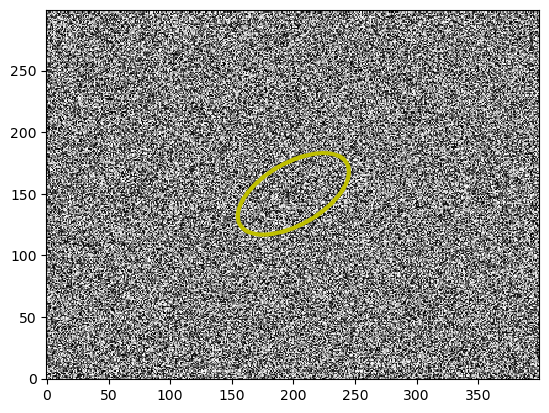

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))

# Plot data

fig, ax = plt.subplots()
ax.imshow(data, interpolation='none', origin="lower", cmap='gray')

# Compute ellipse

xcenter = Nx/2
ycenter = Ny/2
width = 100; height= 50
angle = 30.0
e1 = Ellipse((xcenter, ycenter), width, height, angle=angle, fill=False, color = 'y', linewidth = 3)

# Add ellipse to plot

ax.add_patch(e1)
plt.show()